# 9.7

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## For Cauchy distribution

In [145]:
rng = np.random.default_rng(seed=42)

n_indv_samples = 100
s = rng.standard_cauchy(n_indv_samples)
n_bootstraps = 1000
bootstraps = np.zeros([n_bootstraps, n_indv_samples])

for i in range(n_bootstraps):
    bootstraps[i,:] = rng.choice(s, n_indv_samples, replace=True).reshape(1,-1)

In [146]:
s_mean = np.mean(s)
bs_sample_means = np.mean(bootstraps, axis=1)
bs_mean = np.mean(bs_sample_means)

print(s_mean)
print(bs_mean)

-0.3130435214752563
-0.28898595818986433


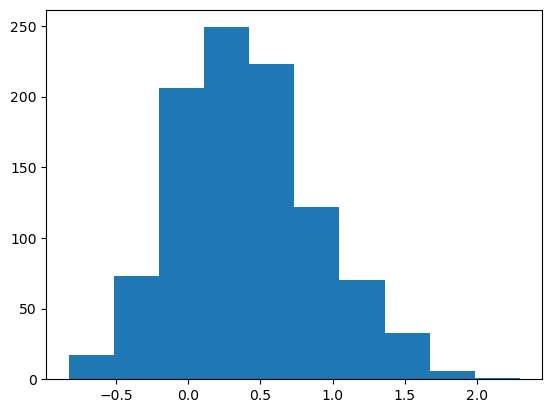

In [93]:
plt.hist(bs_sample_means)
plt.show()

In [94]:
bias_mean = bs_mean - s_mean
print(bias_mean)

bias_corrected_mean = s_mean - bias_mean
print(bias_corrected_mean)

se_bootstrap_means = np.std(bs_sample_means)
print(se_bootstrap_means)

ci95_bs_sample_means = np.percentile(bs_sample_means, [2.5, 97.5])
print(ci95_bs_sample_means)

0.0002247541120819485
0.4044210375632033
0.4838850503313094
[-0.41686674  1.48299322]


In [95]:
np.std(s)

np.float64(4.764226036514621)

We see high variability even for larger original sample sizes, wide confidence intervals. 

## For uniform distribution

In [149]:
rng = np.random.default_rng(seed=42)

n_indv_samples = 100
n_bootstraps = 10000
s_uni = rng.uniform(0, 1, size=n_indv_samples)

bootstraps_uni = np.zeros([n_bootstraps, n_indv_samples])
for i in range(n_bootstraps):
    bootstraps_uni[i,:] = rng.choice(s_uni, n_indv_samples, replace=True)

In [150]:
theta_hat = np.max(s_uni)
print(theta_hat)

0.9756223516367559


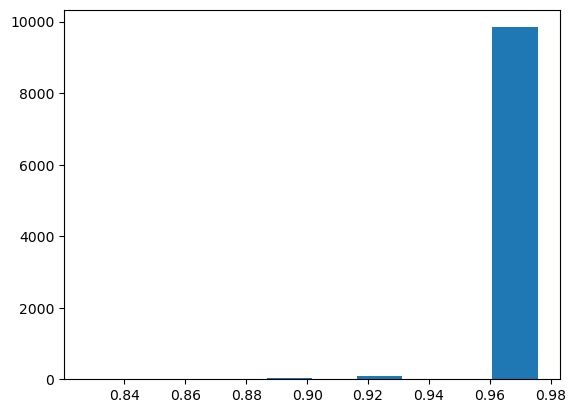

In [151]:
np.mean(np.max(bootstraps_uni, axis=1))

plt.hist(np.max(bootstraps_uni, axis=1))
plt.show()

In [161]:
bootstraps_uni_max = np.max(bootstraps_uni, axis=1)
print(np.percentile(bootstraps_uni_max, [2.5, 97.5]))

print(np.std(bootstraps_uni_max))
print(s_uni.max())

[0.96189766 0.97562235]
0.009272361797299868
0.9756223516367559


The bootstrap samples will never have a higher value than the maximum value of the original sample.